# Assignment 1 2AMM10 2025-2026

## Group: [Fill in your group name]
### Member 1: [Fill in your name]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

In [15]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

# Task 1

In [16]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

<Axes: >

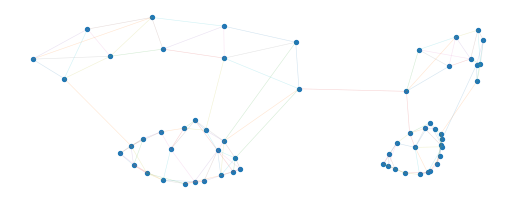

In [17]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

In [18]:

from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.loader import DataLoader
import torch.nn.functional as F


class GraphSAGE(nn.Module):
    """
    GraphSAGE model for graph-level binary classification (awake vs drowsy).

    Architecture (Geometric Deep Learning blueprint):
        [SAGEConv → BN → ReLU → Dropout] × num_layers   # equivariant layers
        → global_mean_pool                                # invariant global pooling
        → MLP head (Linear → ReLU → Dropout → Linear)    # binary classifier

    SAGEConv update rule (mean variant):
        x_i^(k) = W1 * x_i^(k-1)  +  (1/|N(i)|) * Σ_{j ∈ N(i)} x_j^(k-1)

    Parameter re-use across all nodes makes the layer permutation-equivariant.
    Mean aggregation over N(i) is permutation-invariant (nodes have no canonical ordering).

    Output: scalar logit per graph (positive = drowsy).
            Use BCEWithLogitsLoss during training; sigmoid ≥ 0.5 at inference.
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int = 64,
        num_layers: int = 3,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # First layer: in_channels → hidden_channels
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Remaining GNN layers: hidden_channels → hidden_channels
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        # MLP classification head (maps graph embedding → scalar logit)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1),  # scalar output; BCEWithLogitsLoss applies sigmoid
        )

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch: torch.Tensor):
        # Equivariant message-passing layers
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Invariant global pooling: collapse node embeddings into one graph embedding
        x = global_mean_pool(x, batch)  # [num_graphs, hidden_channels]

        # Binary classification head
        return self.mlp(x).squeeze(-1)  # [num_graphs]  (scalar logit per graph)


In [19]:

# ── DataLoaders ──────────────────────────────────────────────────────────────
train_dataset_graph = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset_graph  = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")

BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset_graph, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset_graph,  batch_size=BATCH_SIZE, shuffle=False)

# ── Model, optimiser ─────────────────────────────────────────────────────────
IN_CHANNELS     = train_dataset_graph[0].x.shape[1]  # 3 (x, y, z coordinates)
HIDDEN_CHANNELS = 64    # smaller width reduces overfitting on 400-sample dataset
NUM_LAYERS      = 3
DROPOUT         = 0.3
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
EPOCHS          = 100   # more epochs; cosine LR decays slowly, best checkpoint saved

model     = GraphSAGE(IN_CHANNELS, HIDDEN_CHANNELS, NUM_LAYERS, DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters : {total_params:,}")
print(f"Training samples     : {len(train_dataset_graph)}")
print(f"Test samples         : {len(test_dataset_graph)}")
print(f"Node features        : {IN_CHANNELS}")
print(f"Classes              : {train_dataset_graph.id_to_class}")
print(f"Device               : {DEVICE}")


GraphSAGE(
  (convs): ModuleList(
    (0): SAGEConv(3, 64, aggr=mean)
    (1-2): 2 x SAGEConv(64, 64, aggr=mean)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters : 19,457
Training samples     : 400
Test samples         : 100
Node features        : 3
Classes              : {'0': 'awake', '1': 'drowsy'}
Device               : mps


In [ ]:

# ── Helper functions ─────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, device):
    """One training epoch using BCEWithLogitsLoss (numerically stable binary CE)."""
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        # Labels must be float for BCEWithLogitsLoss
        loss = F.binary_cross_entropy_with_logits(logits, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    """
    Returns (loss, recall, precision) for the positive class (drowsy=1).

    Recall    = TP / (TP + FN)  — fraction of truly drowsy drivers detected.
                Critical in safety-critical driving: a missed drowsy driver
                (FN) prevents a safety alarm from triggering.
    Precision = TP / (TP + FP)  — fraction of drowsy predictions that are correct.

    Task requirement: both metrics must reach ≥ 0.6 on the test set.
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        total_loss += F.binary_cross_entropy_with_logits(logits, batch.y.float()).item() * batch.num_graphs
        preds = (torch.sigmoid(logits) >= 0.5).long()
        all_preds.append(preds.cpu())
        all_labels.append(batch.y.cpu())

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    TP = ((all_preds == 1) & (all_labels == 1)).sum().item()
    FP = ((all_preds == 1) & (all_labels == 0)).sum().item()
    FN = ((all_preds == 0) & (all_labels == 1)).sum().item()

    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    avg_loss  = total_loss / len(loader.dataset)

    return avg_loss, recall, precision


# ── Training loop ─────────────────────────────────────────────────────────────
best_recall   = 0.0
train_losses  = []
test_losses   = []
test_recalls  = []
test_precs    = []

for epoch in range(1, EPOCHS + 1):
    train_loss              = train_epoch(model, train_loader, optimizer, DEVICE)
    test_loss, recall, prec = evaluate(model, test_loader, DEVICE)
    scheduler.step()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_recalls.append(recall)
    test_precs.append(prec)

    # Save best checkpoint based on recall (most safety-critical metric)
    if recall > best_recall:
        best_recall = recall
        torch.save(model.state_dict(), "model_task1_sage.pth")

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{EPOCHS}  |  "
            f"Train Loss: {train_loss:.4f}  |  "
            f"Test Loss: {test_loss:.4f}  |  "
            f"Recall: {recall:.4f}  |  "
            f"Precision: {prec:.4f}"
        )

print(f"\nBest test recall: {best_recall:.4f}")

# ── Final evaluation with best checkpoint ────────────────────────────────────
model.load_state_dict(torch.load("model_task1_sage.pth", weights_only=True))
_, final_recall, final_prec = evaluate(model, test_loader, DEVICE)

print("\n── Final Test Set Results ───────────────────────────────────")
print(f"  Recall    (TP/(TP+FN)): {final_recall:.4f}  {'✓ >= 0.6' if final_recall >= 0.6 else '✗ < 0.6'}")
print(f"  Precision (TP/(TP+FP)): {final_prec:.4f}  {'✓ >= 0.6' if final_prec >= 0.6 else '✗ < 0.6'}")
print("─────────────────────────────────────────────────────────────")


Epoch   1/100  |  Train Loss: 0.6727  |  Test Loss: 0.6902  |  Recall: 0.1000  |  Precision: 0.3125
Epoch  10/100  |  Train Loss: 0.4600  |  Test Loss: 0.4966  |  Recall: 0.6800  |  Precision: 0.7727
Epoch  20/100  |  Train Loss: 0.3982  |  Test Loss: 0.4181  |  Recall: 0.5800  |  Precision: 1.0000
Epoch  30/100  |  Train Loss: 0.3776  |  Test Loss: 0.4193  |  Recall: 0.6000  |  Precision: 0.9375
Epoch  40/100  |  Train Loss: 0.3411  |  Test Loss: 0.3864  |  Recall: 0.6200  |  Precision: 0.9688
Epoch  50/100  |  Train Loss: 0.3584  |  Test Loss: 0.3655  |  Recall: 0.6600  |  Precision: 0.9167
Epoch  60/100  |  Train Loss: 0.3360  |  Test Loss: 0.3505  |  Recall: 0.7800  |  Precision: 0.9512
Epoch  70/100  |  Train Loss: 0.3118  |  Test Loss: 0.3467  |  Recall: 0.8200  |  Precision: 0.9318
Epoch  80/100  |  Train Loss: 0.3290  |  Test Loss: 0.3376  |  Recall: 0.8200  |  Precision: 0.9318
Epoch  90/100  |  Train Loss: 0.3151  |  Test Loss: 0.3325  |  Recall: 0.8200  |  Precision: 0.9318


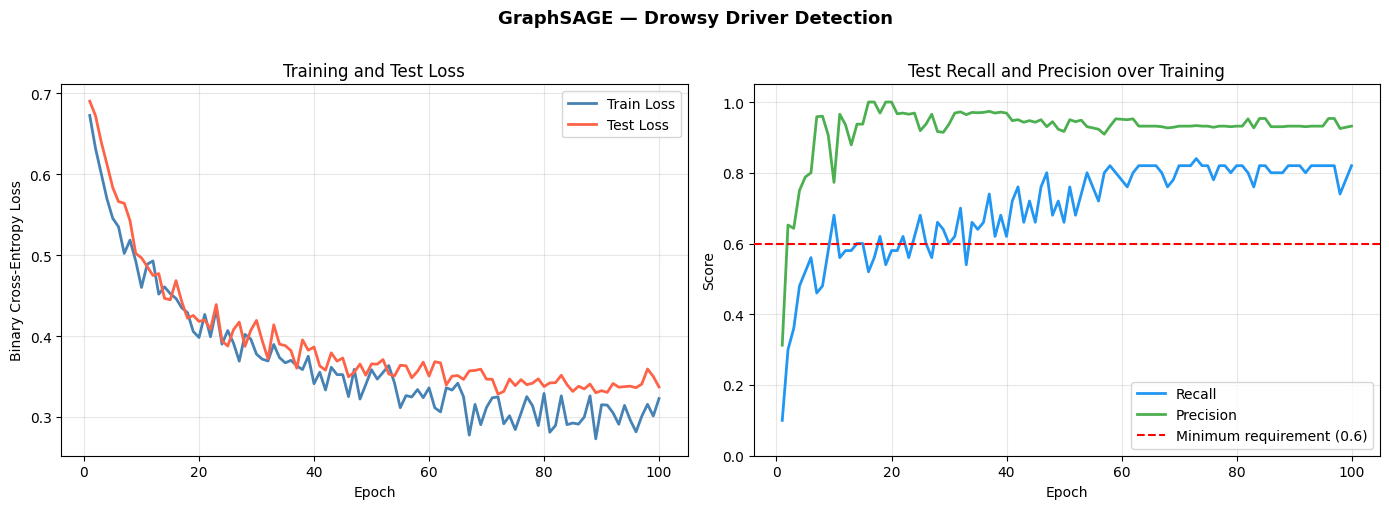

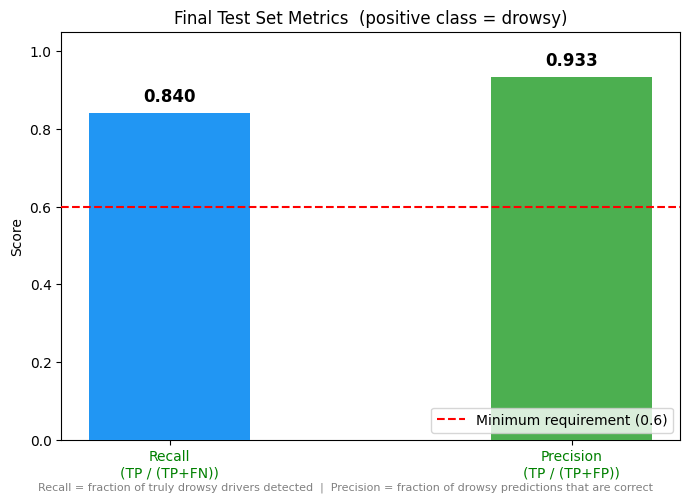

In [21]:

# ── Training curves ────────────────────────────────────────────────────────────
# Run this cell independently to regenerate plots without retraining.

ep = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Loss curves ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(ep, train_losses, label="Train Loss", color="steelblue", linewidth=2)
ax.plot(ep, test_losses,  label="Test Loss",  color="tomato",    linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.set_title("Training and Test Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Right: Recall and Precision over epochs ────────────────────────────────────
ax = axes[1]
ax.plot(ep, test_recalls, label="Recall",    color="#2196F3", linewidth=2)
ax.plot(ep, test_precs,   label="Precision", color="#4CAF50", linewidth=2)
ax.axhline(0.6, color="red", linestyle="--", linewidth=1.5,
           label="Minimum requirement (0.6)", zorder=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Test Recall and Precision over Training")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("GraphSAGE — Drowsy Driver Detection", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Bar chart: final Recall vs Precision ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
names  = ["Recall\n(TP / (TP+FN))", "Precision\n(TP / (TP+FP))"]
values = [final_recall, final_prec]
colors = ["#2196F3", "#4CAF50"]

bars = ax.bar(names, values, color=colors, width=0.4, zorder=3)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.axhline(0.6, color="red", linestyle="--", linewidth=1.5,
           label="Minimum requirement (0.6)", zorder=4)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Final Test Set Metrics  (positive class = drowsy)")
ax.legend(loc="lower right")

for tick, val in zip(ax.get_xticklabels(), values):
    tick.set_color("green" if val >= 0.6 else "red")

fig.text(0.5, 0.01,
         "Recall = fraction of truly drowsy drivers detected  |  "
         "Precision = fraction of drowsy predictions that are correct",
         ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("test_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


# Task 2

In [65]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

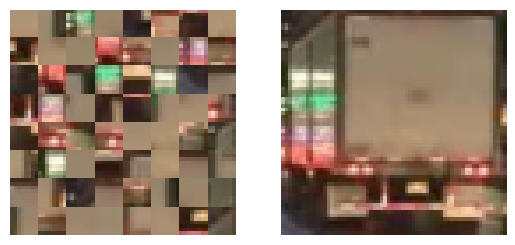

In [66]:
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=None,  # Fill train image transforms
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=None,  # Fill test image transforms
)

### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

In [ ]:
class PatchEmbed(nn.Module):
    def __init__(self, in_channels=3, embed_dim=128, patch_size=8):
        super().__init__()
        self.proj = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        h = self.norm1(x)
        attn_out, _ = self.attn(h, h, h, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class PatchShuffleInvariantTransformer(nn.Module):
    def __init__(
        self,
        num_classes,
        img_size=64,
        patch_size=8,
        embed_dim=128,
        depth=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.1,
    ):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.patch_embed = PatchEmbed(3, embed_dim, patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.blocks = nn.ModuleList(
            [
                TransformerEncoderBlock(embed_dim, num_heads, mlp_ratio, dropout)
                for _ in range(depth)
            ]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        patches = self.patch_embed(x)  # [B, N, D]
        cls = self.cls_token.expand(B, -1, -1)  # [B, 1, D]
        tokens = torch.cat([cls, patches], dim=1)  # [B, 1+N, D]

        for block in self.blocks:
            tokens = block(tokens)
        tokens = self.norm(tokens)

        cls_out = tokens[:, 0]
        logits = self.head(cls_out)
        return logits


In [ ]:
from sklearn.metrics import precision_score, recall_score


def train_model(model, train_loader, device, epochs=15, lr=3e-4, weight_decay=1e-4):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        scheduler.step()

        print(
            f"Epoch {epoch + 1}/{epochs} | loss: {running_loss / total:.4f} "
            f"| train acc: {correct / total:.4f}"
        )
    return model


@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


def compute_metrics(preds, labels, num_classes):
    class_ids = list(range(num_classes))
    per_class_precision = precision_score(
        labels, preds, labels=class_ids, average=None, zero_division=0
    )
    per_class_recall = recall_score(
        labels, preds, labels=class_ids, average=None, zero_division=0
    )
    macro_precision = float(np.mean(per_class_precision))
    macro_recall = float(np.mean(per_class_recall))
    return per_class_precision, per_class_recall, macro_precision, macro_recall


def evaluate(model, loader, device, num_classes):
    preds, labels = collect_predictions(model, loader, device)
    return compute_metrics(preds, labels, num_classes)


def plot_per_class_metrics(class_names, precision, recall, save_path, title):
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    x = np.arange(len(class_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width / 2, precision, width, label="Precision", color="#792577")
    bars2 = ax.bar(x + width / 2, recall, width, label="Recall", color="#E36E2B")

    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.bar_label(bars1, fmt="%.2f", padding=2, fontsize=8)
    ax.bar_label(bars2, fmt="%.2f", padding=2, fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)


In [ ]:
from torchvision import transforms

IMG_SIZE = 64
PATCH_SIZE = 8
EPOCHS = 15
BATCH_SIZE = 32
LR = 3e-4
EMBED_DIM = 128
DEPTH = 4
NUM_HEADS = 4
NUM_WORKERS = 0

base_tf = [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]
train_transform = transforms.Compose(base_tf)                       # clean images
clean_test_transform = transforms.Compose(base_tf)
corrupted_test_transform = transforms.Compose(base_tf + [PatchShuffle(PATCH_SIZE)])


In [ ]:
import argparse

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

IMG_SIZE = 64
PATCH_SIZE = 8


def build_transforms():
    base = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
    train_transform = transforms.Compose(base)  # clean images only, per the spec
    clean_test_transform = transforms.Compose(base)
    corrupted_test_transform = transforms.Compose(base + [PatchShuffle(PATCH_SIZE)])
    return train_transform, clean_test_transform, corrupted_test_transform


def main():

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    train_tf, clean_test_tf, corrupt_test_tf = build_transforms()

    train_ds = BDDObjectClassificationDataset(
        OBJ_CLS_DATASET_DIR, split="train", img_transform=train_tf
    )
    clean_test_ds = BDDObjectClassificationDataset(
        OBJ_CLS_DATASET_DIR, split="test", img_transform=clean_test_tf
    )
    corrupt_test_ds = BDDObjectClassificationDataset(
        OBJ_CLS_DATASET_DIR, split="test", img_transform=corrupt_test_tf
    )

    num_classes = train_ds.num_classes
    class_names = train_ds.classes
    print(f"num_classes={num_classes}, classes={class_names}")

    train_loader = DataLoader(
        train_ds,
        batch_size=16,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    clean_test_loader = DataLoader(
        clean_test_ds, batch_size=16, shuffle=False,
        num_workers=0,
    )
    corrupt_test_loader = DataLoader(
        corrupt_test_ds, batch_size=16, shuffle=False,
        num_workers=0,
    )

    model = PatchShuffleInvariantTransformer(
        num_classes=num_classes,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        embed_dim=64,
        depth=4,
        num_heads=4,
    )

    train_model(model, train_loader, device, epochs=30, lr=1e-4)
    (
        corrupt_per_class_precision,
        corrupt_per_class_recall,
        corrupt_macro_precision,
        corrupt_macro_recall,
    ) = evaluate(model, corrupt_test_loader, device, num_classes)

    for cname, p, r in zip(class_names, corrupt_per_class_precision, corrupt_per_class_recall):
        print(f"  {cname:>15s} | precision: {p:.3f} | recall: {r:.3f}")
    print(f"  Aggregated (macro) precision: {corrupt_macro_precision:.3f}")
    print(f"  Aggregated (macro) recall:    {corrupt_macro_recall:.3f}")

    plot_per_class_metrics(
        class_names,
        corrupt_per_class_precision,
        corrupt_per_class_recall,
        save_path=f"per_class_metrics.png",
        title="Per-Class Precision & Recall (PatchShuffle-Corrupted Test Set)",
    )

    (
        _clean_per_class_precision,
        _clean_per_class_recall,
        clean_macro_precision,
        clean_macro_recall,
    ) = evaluate(model, clean_test_loader, device, num_classes)

    print(f" clean aggregated precision: {clean_macro_precision:.3f}")
    print(f"  corrupt aggregated recall:    {clean_macro_recall:.3f}")
    print(f"corrupted_precision = {corrupt_macro_precision:.4f}")
    print(f"corrupted_recall    = {corrupt_macro_recall:.4f}")
    print(f"clean_precision     = {clean_macro_precision:.4f}")
    print(f"clean_recall        = {clean_macro_recall:.4f}")


if __name__ == "__main__":
    main()

Using device: cpu
num_classes=8, classes=['person', 'rider', 'car', 'truck', 'bus', 'bike', 'traffic light', 'traffic sign']
Epoch 1/30 | loss: 2.0341 | train acc: 0.1787
Epoch 2/30 | loss: 1.9364 | train acc: 0.2304
Epoch 3/30 | loss: 1.8691 | train acc: 0.2662
Epoch 4/30 | loss: 1.8170 | train acc: 0.2808
Epoch 5/30 | loss: 1.7724 | train acc: 0.3179
Epoch 6/30 | loss: 1.7265 | train acc: 0.3488
Epoch 7/30 | loss: 1.6835 | train acc: 0.3663
Epoch 8/30 | loss: 1.6242 | train acc: 0.4004
Epoch 9/30 | loss: 1.5889 | train acc: 0.4104
Epoch 10/30 | loss: 1.5590 | train acc: 0.4200
Epoch 11/30 | loss: 1.5151 | train acc: 0.4325
Epoch 12/30 | loss: 1.4975 | train acc: 0.4421
Epoch 13/30 | loss: 1.4570 | train acc: 0.4600
Epoch 14/30 | loss: 1.4338 | train acc: 0.4662
Epoch 15/30 | loss: 1.4048 | train acc: 0.4854
Epoch 16/30 | loss: 1.3699 | train acc: 0.4971
Epoch 17/30 | loss: 1.3481 | train acc: 0.4971
Epoch 18/30 | loss: 1.3246 | train acc: 0.5196
Epoch 19/30 | loss: 1.3057 | train acc

In [136]:
train_ds = BDDObjectClassificationDataset(OBJ_CLS_DATASET_DIR, split="train", img_transform=train_transform)
clean_test_ds = BDDObjectClassificationDataset(OBJ_CLS_DATASET_DIR, split="test", img_transform=clean_test_transform)
corrupt_test_ds = BDDObjectClassificationDataset(OBJ_CLS_DATASET_DIR, split="test", img_transform=corrupted_test_transform)

num_classes = train_ds.num_classes
class_names = train_ds.classes
print(f"num_classes={num_classes}, classes={class_names}")
print(f"train size={len(train_ds)}, test size={len(clean_test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
clean_test_loader = DataLoader(clean_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
corrupt_test_loader = DataLoader(corrupt_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


num_classes=8, classes=['person', 'rider', 'car', 'truck', 'bus', 'bike', 'traffic light', 'traffic sign']
train size=2400, test size=240


In [137]:
model = PatchShuffleInvariantTransformer(
    num_classes=num_classes,
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
)

model = train_model(model, train_loader, "cpu", epochs=EPOCHS, lr=LR)


Epoch 1/15 | loss: 2.0157 | train acc: 0.1996
Epoch 2/15 | loss: 1.8748 | train acc: 0.2596
Epoch 3/15 | loss: 1.7793 | train acc: 0.3004
Epoch 4/15 | loss: 1.7014 | train acc: 0.3412
Epoch 5/15 | loss: 1.5973 | train acc: 0.3983
Epoch 6/15 | loss: 1.5001 | train acc: 0.4437
Epoch 7/15 | loss: 1.4442 | train acc: 0.4567
Epoch 8/15 | loss: 1.3773 | train acc: 0.4779
Epoch 9/15 | loss: 1.2952 | train acc: 0.5238
Epoch 10/15 | loss: 1.2314 | train acc: 0.5500
Epoch 11/15 | loss: 1.1505 | train acc: 0.5829
Epoch 12/15 | loss: 1.0774 | train acc: 0.6017
Epoch 13/15 | loss: 1.0319 | train acc: 0.6275
Epoch 14/15 | loss: 0.9825 | train acc: 0.6558
Epoch 15/15 | loss: 0.9609 | train acc: 0.6596


In [138]:
(corrupt_per_class_precision,
 corrupt_per_class_recall,
 corrupt_macro_precision,
 corrupt_macro_recall) = evaluate(model, corrupt_test_loader, "cpu", num_classes)

print("--- Corrupted (PatchShuffle) test set ---")
for cname, p, r in zip(class_names, corrupt_per_class_precision, corrupt_per_class_recall):
    print(f"  {cname:>15s} | precision: {p:.3f} | recall: {r:.3f}")
print(f"  Aggregated (macro) precision: {corrupt_macro_precision:.3f}")
print(f"  Aggregated (macro) recall:    {corrupt_macro_recall:.3f}")


--- Corrupted (PatchShuffle) test set ---
           person | precision: 0.607 | recall: 0.567
            rider | precision: 0.478 | recall: 0.367
              car | precision: 0.415 | recall: 0.567
            truck | precision: 0.364 | recall: 0.267
              bus | precision: 0.242 | recall: 0.267
             bike | precision: 0.412 | recall: 0.467
    traffic light | precision: 0.667 | recall: 0.600
     traffic sign | precision: 0.719 | recall: 0.767
  Aggregated (macro) precision: 0.488
  Aggregated (macro) recall:    0.483


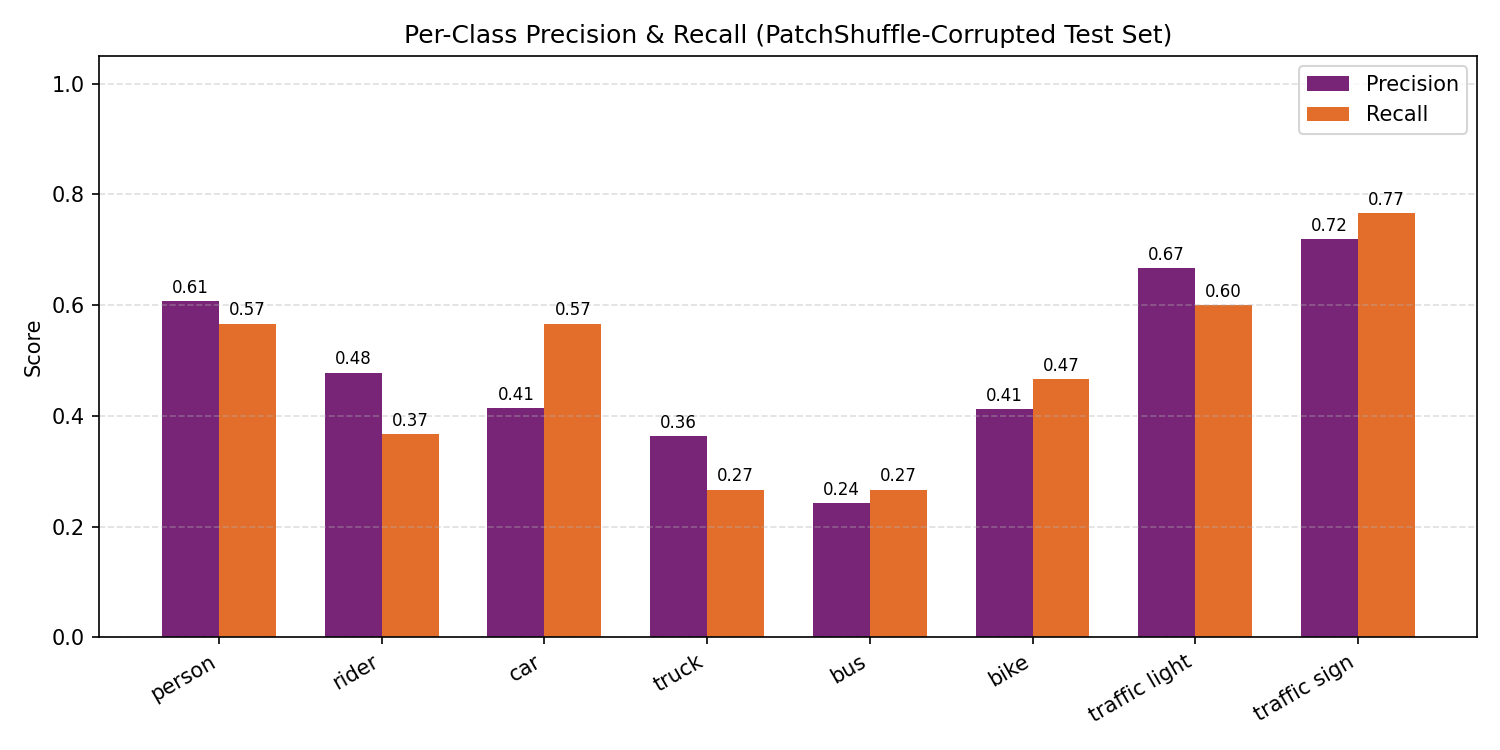

In [142]:
plot_per_class_metrics(
    class_names,
    corrupt_per_class_precision,
    corrupt_per_class_recall,
    save_path="per_class_metrics.png",
    title="Per-Class Precision & Recall (PatchShuffle-Corrupted Test Set)",
)

# Display inline in the notebook
from IPython.display import Image as IPyImage
IPyImage(filename="per_class_metrics.png")


In [ ]:
(_clean_per_class_precision,
 _clean_per_class_recall,
 clean_macro_precision,
 clean_macro_recall) = evaluate(model, clean_test_loader, "cpu", num_classes)

print("--- Clean (uncorrupted) test set ---")
print(f"  Aggregated (macro) precision: {clean_macro_precision:.3f}")
print(f"  Aggregated (macro) recall:    {clean_macro_recall:.3f}")

print("\n=== Final 4 aggregated scalars ===")
print(f"corrupted_precision = {corrupt_macro_precision:.4f}")
print(f"corrupted_recall    = {corrupt_macro_recall:.4f}")
print(f"clean_precision     = {clean_macro_precision:.4f}")
print(f"clean_recall        = {clean_macro_recall:.4f}")



--- Clean (uncorrupted) test set ---
  Aggregated (macro) precision: 0.488
  Aggregated (macro) recall:    0.483

=== Final 4 aggregated scalars ===
corrupted_precision = 0.4879
corrupted_recall    = 0.4833
clean_precision     = 0.4879
clean_recall        = 0.4833

Baseline requirement met (>=0.3 precision and recall on corrupted test set).


# Task 3

In [ ]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()
        self.backbone = None  # Here you can use a function that creates the backbone model based on the backbone_arch string (take a look here: https://docs.pytorch.org/vision/main/models.html)

        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.

        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.

        # TODO: define the trainable linear classification head
        self.linear_head = None

    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.

        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        pass